# BANK LOAN ANALYSIS REPORT

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px


Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_excel("/Users/alifnathani/Documents/financial_loan.xlsx")

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### Metadata of data

In [5]:
print("No of Rows:", df.shape[0])

No of Rows: 38576


In [7]:
print("No of Columns:", df.shape[1])

No of Columns: 24


### Data types

In [9]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

### Total Loan Applications

In [10]:
total_loan_application = df['id'].count()
print("Total Loan Applications:",total_loan_application)

Total Loan Applications: 38576


### MTD Total Loan Applications

In [12]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD Loan Applications (for December 2021): 4314


### Total Funded Amount

In [15]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/ 1000000
print ("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD - Total Funded Amount

In [18]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/ 1000000

print("MTD Total Funded Amount: ${:.2f}M".format(mtd_total_funded_amount_millions))

MTD Total Funded Amount: $53.98M


### Total Amount Received

In [20]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received/ 1000000
print ("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $473.07M


### MTD - Total Amount Received

In [22]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received/ 1000000

print("MTD Total Amount Received: ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount Received: $58.07M


### Average Interest Rate

In [25]:
average_interest_rate = df['int_rate'].mean()*100
print("Average Interest Rate: {:.2f}%".format(average_interest_rate))

Average Interest Rate: 12.05%


### Average Debt-to-Income Ratio (DTI)

In [26]:
average_dti = df['dti'].mean()*100
print("Average DTI: {:.2f}%".format(average_dti))

Average DTI: 13.33%


### Good Loan Metrics

In [31]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount/ 1000000
good_loan_received_millions = good_loan_received/ 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))


Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


### Bad Loan Metrics

In [32]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount/ 1000000
bad_loan_received_millions = bad_loan_received/ 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))


Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


### Monthly Trend by Issue Date for Total Funded Amount

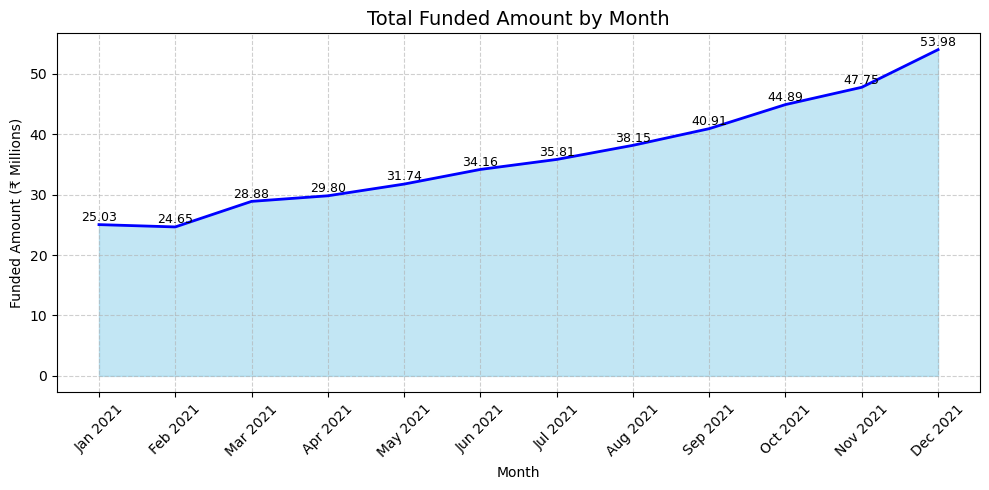

In [9]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='blue', linewidth=2)

# Fixed: Changed iterows() to iterrows() - the correct pandas method name
for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
# Fixed: Changed plt.xlable to plt.xlabel (typo in function name)
plt.xlabel('Month')
plt.ylabel('Funded Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




### Monthly Trend by Issue Date for Total Amount Received

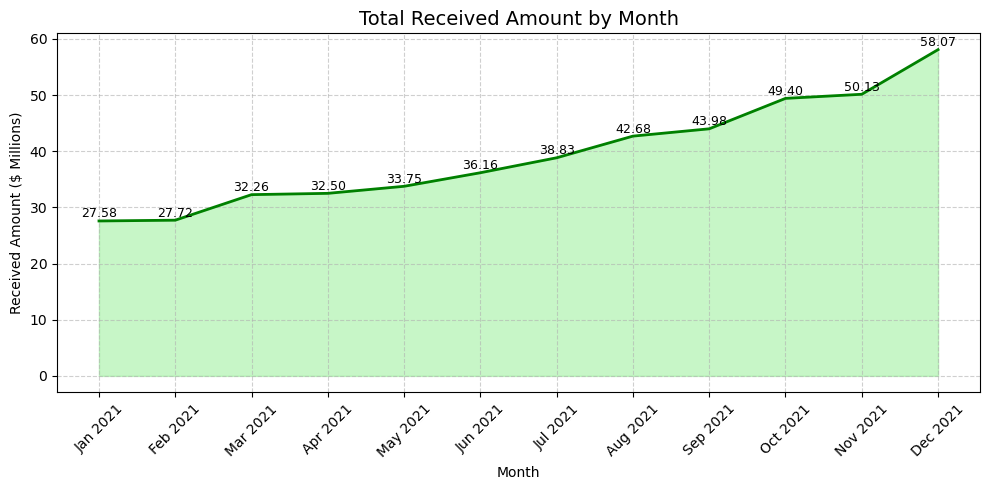

In [3]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Use read_excel instead of read_csv for .xlsx files
df = pd.read_excel("/Users/alifnathani/Documents/financial_loan.xlsx")

monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name'], monthly_received['received_amount_millions'], 
                 color='lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'], monthly_received['received_amount_millions'], 
                 color='green', linewidth=2)

for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trend by Issue Date for Total Loan Applications

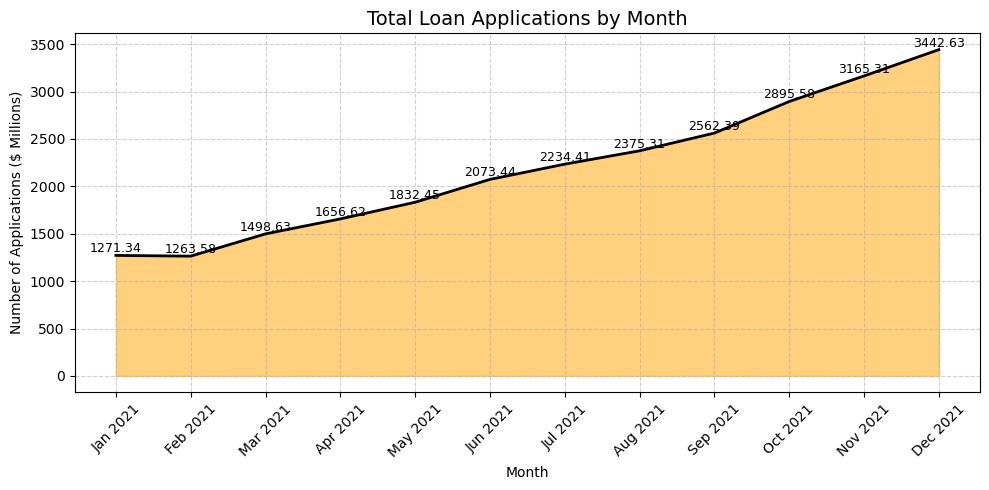

In [6]:
monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .sum()
    .div(1000000)
    .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_applications['month_name'], monthly_applications['loan_applications_count'], 
                 color='orange', alpha=0.5)
plt.plot(monthly_applications['month_name'], monthly_applications['loan_applications_count'], 
                 color='black', linewidth=2)

# Fixed: Changed monthly_received to monthly_applications to use the correct DataFrame
for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.1, f"{row['loan_applications_count']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications (₹ Millions)')

# Fixed: Changed monthly_received to monthly_applications to use the correct DataFrame
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

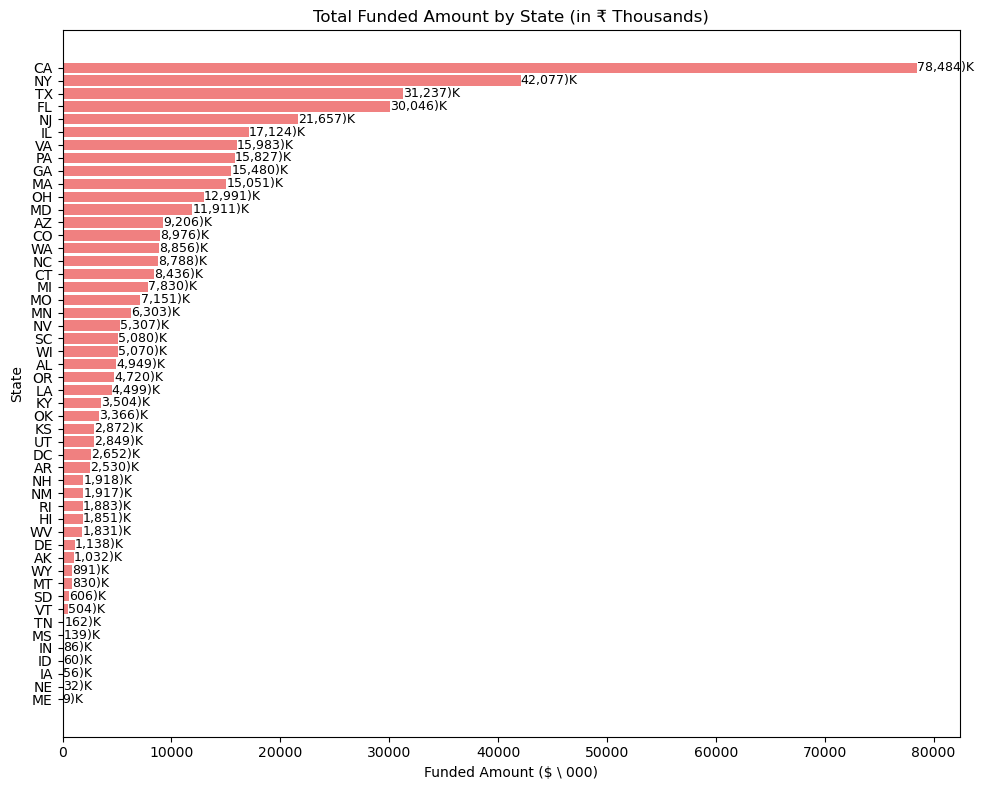

In [8]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars= plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f})K', va='center' , fontsize=9)

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel('Funded Amount (₹ \ 000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Amount Received

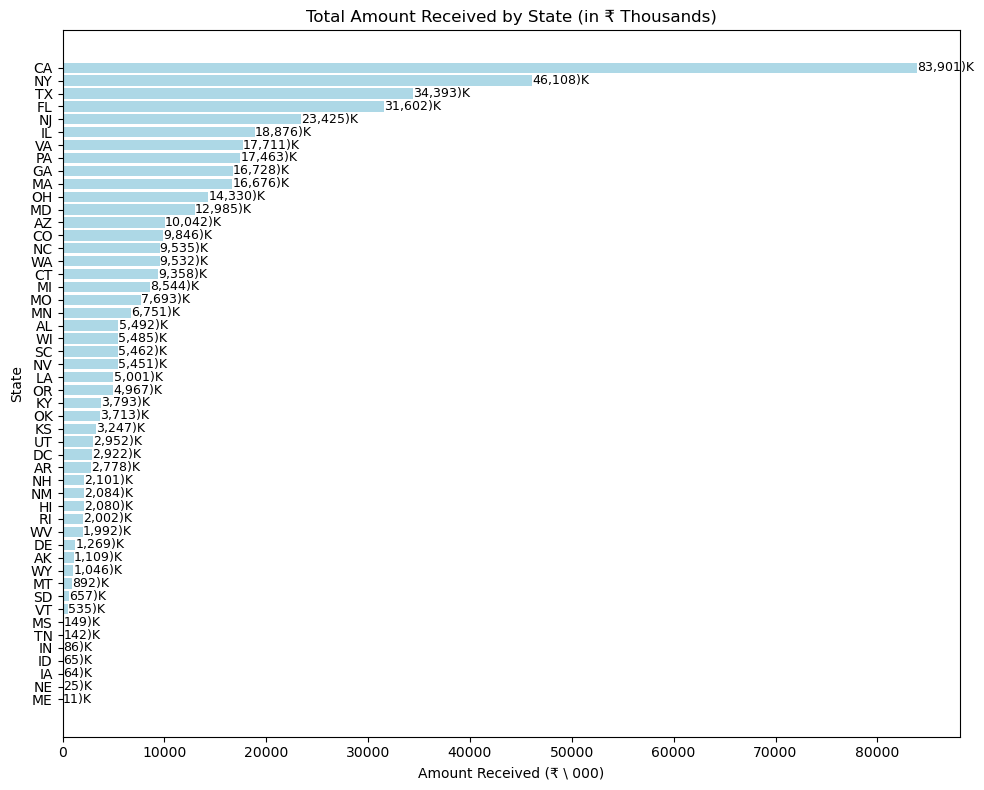

In [10]:
state_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_received_thousands = state_received / 1000

plt.figure(figsize=(10, 8))
bars= plt.barh(state_received_thousands.index, state_received_thousands.values, color='lightblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f})K', va='center' , fontsize=9)

plt.title('Total Amount Received by State (in ₹ Thousands)')
plt.xlabel('Amount Received (₹ \ 000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Loan Applications

/var/folders/jx/s3qhz04x49bgrxpq5fjf3drm0000gn/T/ipykernel_1791/24889182.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


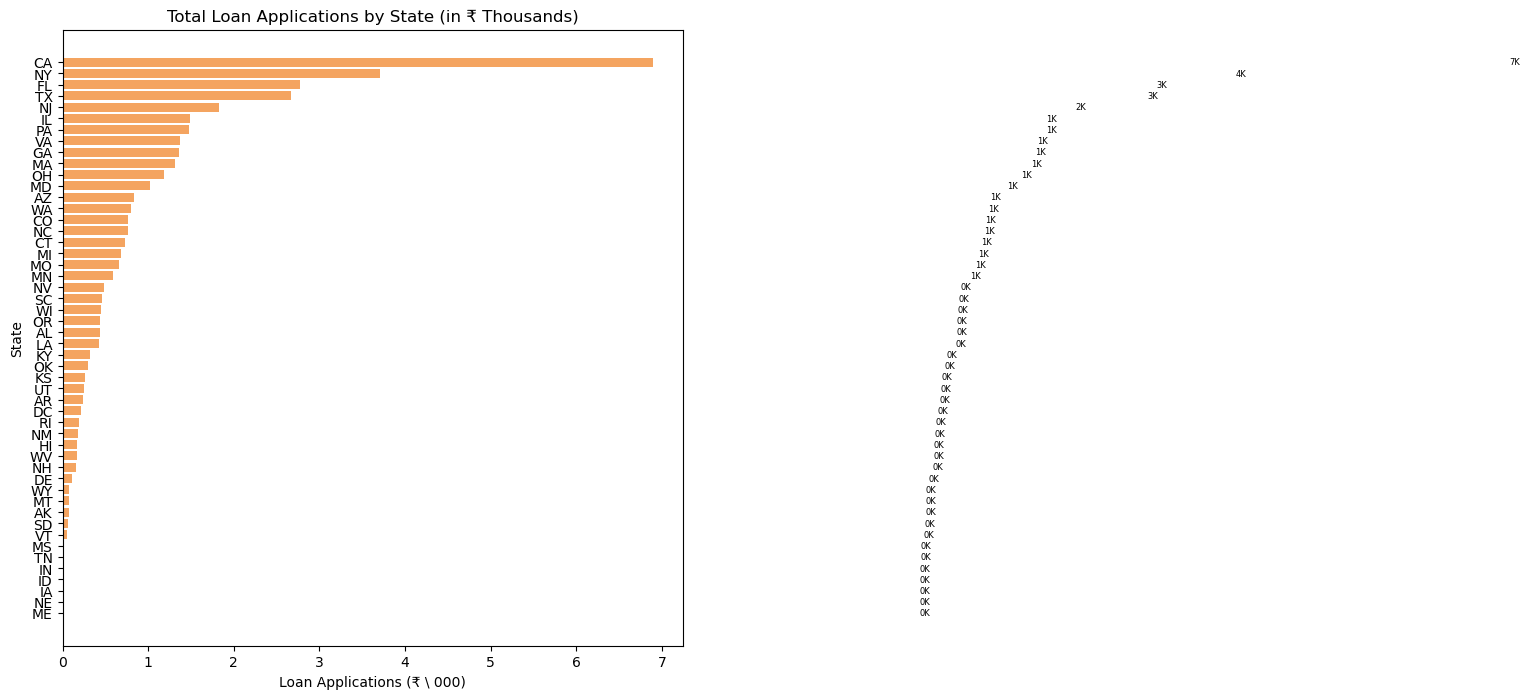

In [14]:
# First, we need to create the loan_applications_count column if it doesn't exist
# Assuming you want to count loan applications per state
df['loan_applications_count'] = 1  # Each row represents one application

# Now group by state and sum the counts
state_loan_applications = df.groupby('address_state')['loan_applications_count'].sum().sort_values(ascending=True)
state_loan_applications_thousands = state_loan_applications / 1000

plt.figure(figsize=(8, 8))
# Changed 'lightbrown' to a standard color name that matplotlib recognizes
bars = plt.barh(state_loan_applications_thousands.index, state_loan_applications_thousands.values, color='sandybrown')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f}K', va='center', fontsize=6)  # Fixed parenthesis in f-string

plt.title('Total Loan Applications by State (in ₹ Thousands)')
plt.xlabel('Loan Applications (₹ \\ 000)')  # Fixed escape character
plt.ylabel('State')
plt.tight_layout()
plt.show()